In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.datasets import make_blobs

In [3]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=3, random_state=42)

In [4]:
# Perform hierarchical clustering with the AgglomerativeClustering algo
clustering = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='average'
)

clustering.fit(X)

AgglomerativeClustering(linkage='average', n_clusters=3)

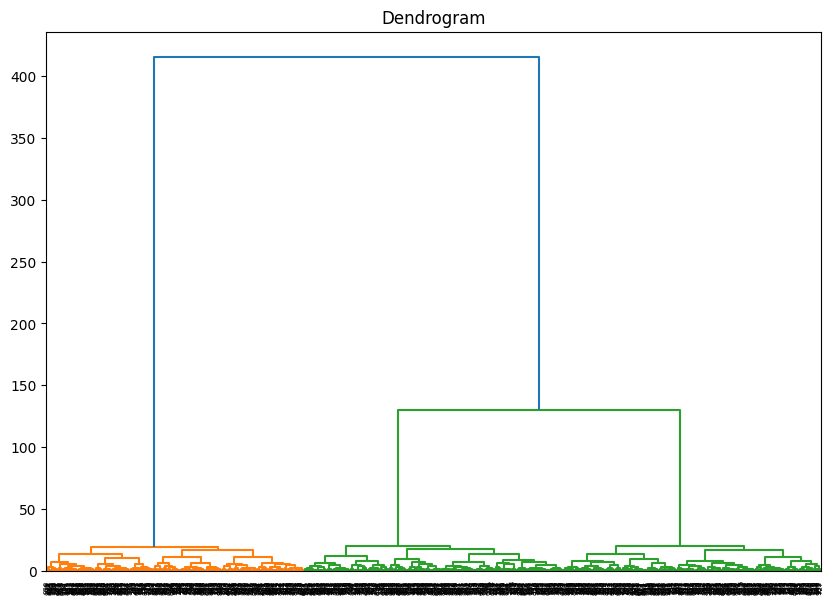

In [5]:
# Plot the dendogram
plt.figure(figsize=(10,7))
plt.title("Dendrogram")

sch.dendrogram(
    sch.linkage(X, method='ward')
)

plt.show()

## Now show in tips datasets

In [6]:
df = sns.load_dataset('tips')

In [8]:
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering

# Load dataset
df = sns.load_dataset('tips')

# Select numeric features
X = df[['total_bill', 'tip', 'size']]

# Create model
clustering = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

# Fit and predict
df['Cluster'] = clustering.fit_predict(X)

print(df.head())
print(df['Cluster'].value_counts())

   total_bill   tip     sex smoker  day    time  size  Cluster
0       16.99  1.01  Female     No  Sun  Dinner     2        1
1       10.34  1.66    Male     No  Sun  Dinner     3        2
2       21.01  3.50    Male     No  Sun  Dinner     3        1
3       23.68  3.31    Male     No  Sun  Dinner     2        1
4       24.59  3.61  Female     No  Sun  Dinner     4        1
Cluster
2    111
1     96
0     37
Name: count, dtype: int64


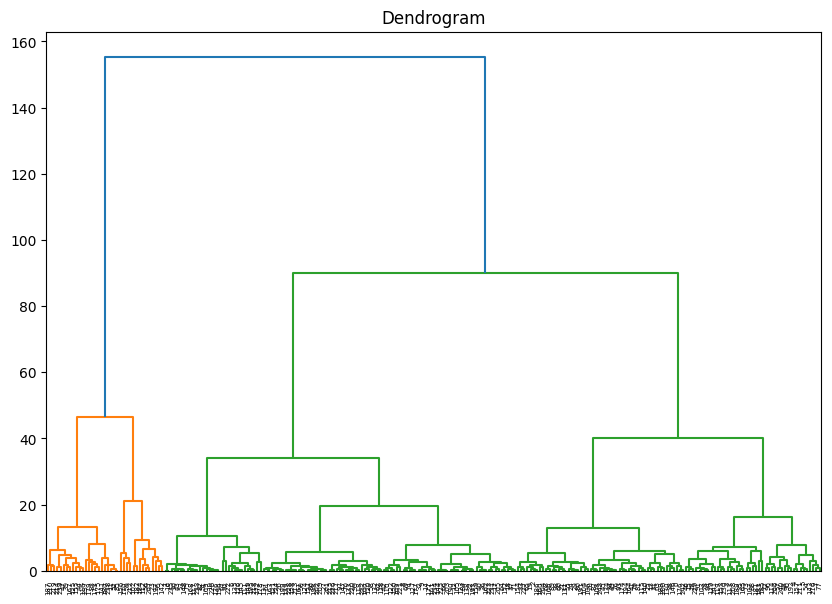

In [9]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.title("Dendrogram")
sch.dendrogram(sch.linkage(X, method='ward'))
plt.show()

## Evaluation metric

## 1. Silhouette Score

In [11]:
from sklearn.metrics import silhouette_score
clustering.fit(X)

labels = clustering.labels_

score = silhouette_score(X, labels)

print(score)

0.48973798501852606


## 2. Davies-Bouldin Index

In [12]:
from sklearn.metrics import davies_bouldin_score

dbi = davies_bouldin_score(X, labels)
print("DBI:", dbi)

DBI: 0.6295944768033522


## 3. Calinski-Harabasz Index

In [13]:
from sklearn.metrics import calinski_harabasz_score

chi = calinski_harabasz_score(X, labels)
print("CHI:", chi)

CHI: 504.0600414976475


## 4. Normalized Mutual Information (NMI)

In [16]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

print("Silhouette Score:", silhouette_score(X, labels))
print("Davies-Bouldin Index:", davies_bouldin_score(X, labels))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X, labels))

Silhouette Score: 0.48973798501852606
Davies-Bouldin Index: 0.6295944768033522
Calinski-Harabasz Score: 504.0600414976475
